# Spatio-Temporal Environmental Monitoring via Satellite Imagery
## Project Overview
This project implements a high-resolution monitoring system for the **Aravalli Range** using **Sentinel-2 Satellite Imagery** and **Deep Learning (ConvLSTM)**. It is designed to detect land-use transitions—specifically illegal mining and deforestation—by analyzing image sequences from **2020 to 2026**.

### Key Objectives:
* **Automated Data Retrieval:** Integration with Google Earth Engine (GEE) for multi-spectral data.
* **Temporal Analysis:** Using ConvLSTM layers to capture "movement" and degradation over time.
* **Classification-Task Learning:** Simultaneous classification of land types  for forest loss.

In [1]:
def import_libraries():
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import warnings
    %matplotlib inline
    warnings.filterwarnings("ignore")
    import tensorflow as tf
    import geemap
    import ee
    import os
    from dotenv import load_dotenv
    from rasterio.windows import Window
    import rasterio
    import shutil
    import keras
    import collections
    import random
    import seaborn as sns
    import folium
    import pickle
    from tensorflow.keras import layers,models,regularizers
    from tensorflow.keras.layers import TimeDistributed 
    from tensorflow.keras.optimizers import Adam
    from sklearn.model_selection import train_test_split
    from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
    from tensorflow.keras.layers import GlobalAveragePooling2D,Attention
    from sklearn.metrics import confusion_matrix, classification_report
    from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array,load_img
    from tensorflow.keras.layers import ConvLSTM2D, Dropout, Dense
    from sklearn.utils.class_weight import compute_class_weight
    return np,pd,plt,warnings,tf,ee,os,load_dotenv,geemap,Window,rasterio,shutil,layers,models,keras,ImageDataGenerator,img_to_array,load_img,random,TimeDistributed,train_test_split,collections,EarlyStopping,Adam,ReduceLROnPlateau,sns,confusion_matrix,classification_report,folium,pickle,ConvLSTM2D,Dropout,Dense,GlobalAveragePooling2D,Attention,compute_class_weight,regularizers

np,pd,plt,warnings,tf,ee,os,load_dotenv,geemap,Window,rasterio,shutil,layers,models,keras,ImageDataGenerator,img_to_array,load_img,random,TimeDistributed,train_test_split,collections,EarlyStopping,Adam,ReduceLROnPlateau,sns,confusion_matrix,classification_report,folium,pickle,ConvLSTM2D,Dropout,Dense,GlobalAveragePooling2D,Attention,compute_class_weight,regularizers= import_libraries()
print("Import done")
    

Import done


In [2]:
def earth_engine():
    load_dotenv()
    print("Dotenv loaded successfully")
    load_dotenv(override=True)
    project_id = os.getenv("GEE_PROJECT_ID")
    if not project_id:
        print("❌ ERROR: GEE_PROJECT_ID is empty! Check your .env file.")
        return None
    
    print(f"Loaded Project ID: {project_id}")
    try:
        ee.Authenticate(force=True, auth_mode='notebook')
        ee.Initialize(project=project_id)
        print(f"Initailzation process done successfully with project id :{project_id}")
    except Exception as e:
        print("Existing credentials not found or expired. Authenticating...")
        try:
            ee.Authenticate(auth_mode="localhost")
            ee.Initialize(project=project_id)
            print(f"Initailzation process done successfully with project id :{project_id}")
        except Exception as e:    
            print(f"Initialization process failed.Check Your Project Id  as Error:{e} ")    

    return project_id
project_id = earth_engine()
project_id

Dotenv loaded successfully
Loaded Project ID: aravalli-mining-detector


Existing credentials not found or expired. Authenticating...
Initailzation process done successfully with project id :aravalli-mining-detector


'aravalli-mining-detector'

## Data Pipeline
### 1. Spatial Coverage
The project monitors 18 strategic locations including Manesar, Sohna, Mangar, Pali, and Nuh etc.

### 2. Spectral Indices
The core analytical unit is the **Normalized Difference Vegetation Index (NDVI)**, calculated using Sentinel-2 Bands 4 (Red) and 8 (NIR):
$$NDVI = \frac{B8 (NIR) - B4 (Red)}{B8 (NIR) + B4 (Red) + 1e^{-10}}$$

In [3]:
locations = [
    {"name": "manesar-south", "coords": [76.9900, 28.3000]},
    {"name": "manesar-north", "coords": [76.9900, 28.3500]},
    {"name": "sohna-south",   "coords": [77.0500, 28.2200]},
    {"name": "sohna-north",   "coords": [77.0500, 28.2700]},
    {"name": "mangar-south",  "coords": [77.1731, 28.3500]},
    {"name": "mangar-north",  "coords": [77.1731, 28.4000]},
    {"name": "pali-south",    "coords": [77.2100, 28.3100]},
    {"name": "pali-north",    "coords": [77.2100, 28.3600]},
    {"name": "nuh-north",     "coords": [77.0100, 28.1500]}, 
    {"name": "nuh-south",     "coords": [77.0200, 27.8500]},
    {"name": "mining-pali",    "coords": [77.2285, 28.3412]},
    {"name": "mining-mewat",   "coords": [77.0421, 27.9150]},
    {"name": "mining-farid",   "coords": [77.2850, 28.4120]},
    {"name": "degradation-khetri", "coords": [75.7800, 28.0000]},
    {"name": "degradation-makrana", "coords": [74.7200, 26.8800]},
    {"name": "desert-gap-ajmer", "coords": [74.6300, 26.4500]},
    {"name": "degradation-bhilwara", "coords": [74.6400, 25.3500]},
    {"name": "degradation-chittorgarh", "coords": [74.6200, 24.8800]}
]




def get_yearly_composite(year):
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterDate(start, end)
                  .select(['B4', 'B3', 'B2', 'B8']))

    size = collection.size().getInfo()

    if size == 0:
        print(f"No images for year {year}")
        return None

    return collection.median()

In [4]:
def data_wrangling():

    exports = []

    for loc in locations:

        name = loc["name"]
        target_point = ee.Geometry.Point(loc["coords"])
        roi = target_point.buffer(320).bounds()

        for year in range(2020, 2027):

            filename = f"{name}_{year}.tif"

            if os.path.exists(filename):
                print(filename, "already exists")
                continue

            image = get_yearly_composite(year).clip(roi)

            geemap.ee_export_image(
                image,
                filename=filename,
                scale=10,
                region=roi
            )

        exports.append(name)

    return exports
data_wrangling()


manesar-south_2020.tif already exists
manesar-south_2021.tif already exists
manesar-south_2022.tif already exists
manesar-south_2023.tif already exists
manesar-south_2024.tif already exists
manesar-south_2025.tif already exists
manesar-south_2026.tif already exists
manesar-north_2020.tif already exists
manesar-north_2021.tif already exists
manesar-north_2022.tif already exists
manesar-north_2023.tif already exists
manesar-north_2024.tif already exists
manesar-north_2025.tif already exists
manesar-north_2026.tif already exists
sohna-south_2020.tif already exists
sohna-south_2021.tif already exists
sohna-south_2022.tif already exists
sohna-south_2023.tif already exists
sohna-south_2024.tif already exists
sohna-south_2025.tif already exists
sohna-south_2026.tif already exists
sohna-north_2020.tif already exists
sohna-north_2021.tif already exists
sohna-north_2022.tif already exists
sohna-north_2023.tif already exists
sohna-north_2024.tif already exists
sohna-north_2025.tif already exists


['manesar-south',
 'manesar-north',
 'sohna-south',
 'sohna-north',
 'mangar-south',
 'mangar-north',
 'pali-south',
 'pali-north',
 'nuh-north',
 'nuh-south',
 'mining-pali',
 'mining-mewat',
 'mining-farid',
 'degradation-khetri',
 'degradation-makrana',
 'desert-gap-ajmer',
 'degradation-bhilwara',
 'degradation-chittorgarh']

In [5]:
def create_sequence_patches(locations):
    patch_dir = "dataset/Sequence_Patches"

    if os.path.exists(patch_dir):
        shutil.rmtree(patch_dir)

    os.makedirs(patch_dir, exist_ok=True)

    total_patches = 0

    for loc in locations:
        loc_name = loc["name"]

        # Load 7 yearly images
        yearly_images = []
        for year in range(2020, 2027):
            tif_file = f"{loc_name}_{year}.tif"
            if not os.path.exists(tif_file):
                print(f"{tif_file} not found")
                continue

            src = rasterio.open(tif_file)
            yearly_images.append(src)

        if len(yearly_images) != 7:
            print(f"Skipping {loc_name}, incomplete years")
            continue

        height = yearly_images[0].height
        width = yearly_images[0].width

        for i in range(0, height - 64 + 1):
            for j in range(0, width - 64 + 1):

                sequence = []

                for src in yearly_images:
                    window = Window(j, i, 64, 64)
                    patch = src.read(window=window)
                    sequence.append(patch)

                sequence = np.stack(sequence, axis=0)  
                sequence = np.transpose(sequence, (0,2,3,1))  

                np.save(f"{patch_dir}/{loc_name}_{i}_{j}.npy", sequence)

                total_patches += 1

        for src in yearly_images:
            src.close()

    print(f"Total sequence patches: {total_patches}")
    return total_patches
create_sequence_patches(locations)
print("Patches Created Successfully")

Total sequence patches: 360
Patches Created Successfully


### 3. Classification Logic
Land is categorized based on its 2026 NDVI values:
* **Class 0**: Active mining / Barren land (NDVI < 0.25)
* **Class 1**: Sparse/Moderate vegetation (0.25 ≤ NDVI < 0.50)
* **Class 2**: Dense vegetation / Forest (NDVI ≥ 0.50)

In [6]:
def automated_sequence_labeling():

    source_folder = "dataset/Sequence_Patches"

    X = []
    y_class = []
    y_loss = []

    for file in os.listdir(source_folder):

        if not file.endswith(".npy"):
            continue

        sequence = np.load(os.path.join(source_folder, file))
        ndvi_sequence = (sequence[:,:,:,3] - sequence[:,:,:,0]) / \
                        (sequence[:,:,:,3] + sequence[:,:,:,0] + 1e-10)

        
        ndvi_2026_mean = np.mean(ndvi_sequence[-1])

        if ndvi_2026_mean < 0.25:
            class_label = 0
        elif 0.25 <= ndvi_2026_mean < 0.5:
            class_label = 1
        else:
            class_label = 2
        ndvi_2020_mean = np.mean(ndvi_sequence[0])
        forest_loss = ndvi_2020_mean - ndvi_2026_mean

        X.append(sequence)
        y_class.append(class_label)
        y_loss.append(forest_loss)

    X = np.array(X)
    y_class = np.array(y_class)
    y_loss = np.array(y_loss)

    print("Dataset prepared")
    print("Shape:", X.shape)

    return X, y_class, y_loss
X, y_class, y_loss = automated_sequence_labeling()
print("Class labels shape:", y_class.shape)
print("Loss labels shape:", y_loss.shape)

Dataset prepared
Shape: (360, 7, 64, 64, 4)
Class labels shape: (360,)
Loss labels shape: (360,)


In [7]:
def train_test(X, y_class, y_loss):

    X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss = train_test_split(
        X,
        y_class,
        y_loss,
        test_size=0.4,
        random_state=42,
        stratify=y_class
    )

    return X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss
X_train_raw, X_test, y_train_class, y_test_class, y_train_loss, y_test_loss = train_test(X, y_class, y_loss)
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test.shape)

Train shape: (216, 7, 64, 64, 4)
Test shape: (144, 7, 64, 64, 4)


## 4. Methodology
### 4.1 Data Augmentation
To improve model robustness, the training set is expanded using spatial flips, signal noise, and radiometric adjustments (brightness scaling).

### 4.2 Preprocessing
* **Standardization**: Data is normalized using the mean and standard deviation of the training set.
* **Splitting**: A 60/40 stratified split is used to maintain class balance between training and testing.

In [21]:
def standarization(X_train_raw, X_test):

    mean = np.mean(X_train_raw, axis=(0,1,2,3), keepdims=True)
    std = np.std(X_train_raw, axis=(0,1,2,3), keepdims=True) + 1e-8

    X_train_norm = (X_train_raw - mean) / std
    X_test_norm = (X_test - mean) / std

    return X_train_norm, X_test_norm


X_train_norm, X_test_norm = standarization(X_train_raw, X_test)


In [27]:
def augment_sequence_data_balanced(X, y_c, y_l):
    X_aug, y_c_aug, y_l_aug = [], [], []

    for i in range(len(X)):
        img = X[i]
        label_c = y_c[i]
        label_l = y_l[i]
        base_augs = [
            img, 
            np.flip(img, axis=2), 
            np.flip(img, axis=1),
            np.clip(img + np.random.normal(0, 0.01, img.shape), -3, 3),
            np.clip(img * np.random.uniform(0.9, 1.1), -3, 3)
        ]

        if label_c == 0:
            extra_augs = [
                np.rot90(img, k=1, axes=(1, 2)),
                np.rot90(img, k=2, axes=(1, 2)), 
                np.rot90(img, k=3, axes=(1, 2)), 
                np.clip(img + np.random.normal(0, 0.02, img.shape), -3, 3), 
                np.clip(img * 0.85, -3, 3) 
            ]
            base_augs.extend(extra_augs)

        for augmented_img in base_augs:
            X_aug.append(augmented_img)
            y_c_aug.append(label_c)
            y_l_aug.append(label_l)

    return np.array(X_aug), np.array(y_c_aug), np.array(y_l_aug)


X_train_final, y_train_class_final, y_train_loss_final = augment_sequence_data_balanced(
    X_train_norm, y_train_class, y_train_loss
)

unique, counts = np.unique(y_train_class_final, return_counts=True)
print("New Training Distribution:", dict(zip(unique, counts)))

New Training Distribution: {np.int64(0): np.int64(330), np.int64(1): np.int64(575), np.int64(2): np.int64(340)}


## 5. Model Architecture: Hybrid CNN-BiLSTM with Self-Attention
This model treats the 7-year satellite sequence as a temporal stream, utilizing spatial feature extraction and recurrent temporal analysis.

### Technical Layers:
1. **TimeDistributed CNN:** Extracts hierarchical spatial features (32, 64, 128 filters) independently for each year.
2. **Bidirectional LSTM:** Processes the sequence in forward and backward directions to capture subtle land-use trends.
3. **Self-Attention Mechanism:** Learns to "weight" specific years in the sequence that are most relevant to the final classification (e.g., the specific year a forest was cleared).
4. **Regularization:** Includes **Batch Normalization**, **Dropout (0.6)**, and **L2 Regularization** to mitigate overfitting.

In [ ]:
def build_improved_classification_model(input_shape=(7, 64, 64, 4), num_classes=3):
    inputs = layers.Input(shape=input_shape)
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x) 
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x) 
    att_weights = layers.Dense(1)(x)
    att_weights = layers.Softmax(axis=1)(att_weights)
    x_weighted = layers.Multiply()([x, att_weights])
    x_final = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x_weighted)
    x = layers.Dense(64, activation='relu', kernel_regularizer='l2')(x_final)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="class_output")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_improved_classification_model()
model

<Functional name=functional_4, built=True>

Epoch 1/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5325 - loss: 1.8106 - val_accuracy: 0.7847 - val_loss: 1.6917 - learning_rate: 5.0000e-05
Epoch 2/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6771 - loss: 1.5911 - val_accuracy: 0.7986 - val_loss: 1.4446 - learning_rate: 5.0000e-05
Epoch 3/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7863 - loss: 1.4232 - val_accuracy: 0.8403 - val_loss: 1.3193 - learning_rate: 5.0000e-05
Epoch 4/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8193 - loss: 1.3244 - val_accuracy: 0.8472 - val_loss: 1.2341 - learning_rate: 5.0000e-05
Epoch 5/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8386 - loss: 1.2654 - val_accuracy: 0.8472 - val_loss: 1.1512 - learning_rate: 5.0000e-05
Epoch 6/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8683 - loss: 1.1933 - val_accuracy: 0.9028 - val_loss: 1.0717 - learning_rate: 5.0000e-05
Epoch 7/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8956 - loss:

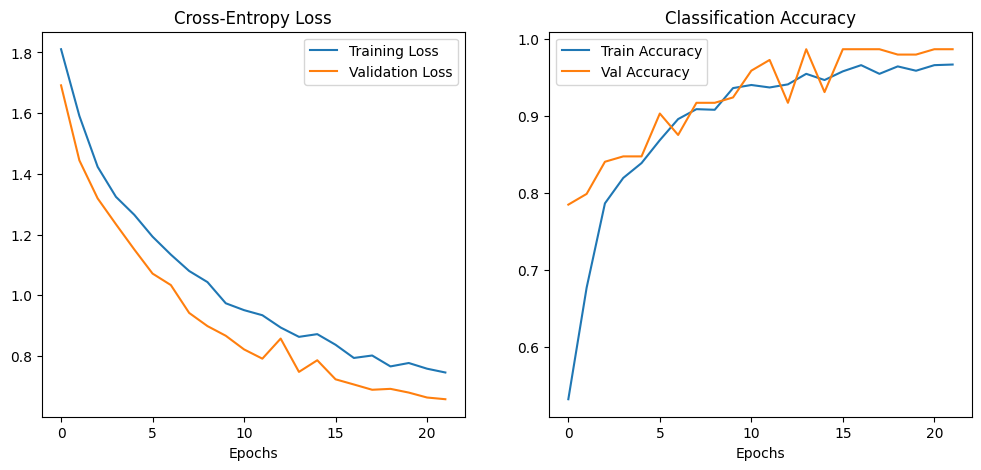

In [30]:
indices = np.arange(len(X_train_final))
np.random.shuffle(indices)
X_train_shuffled = X_train_final[indices]
y_train_shuffled = y_train_class_final[indices]
def model_trained():
    early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
    lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6)

    history = model.fit(
        X_train_shuffled,
        y_train_shuffled, 
        validation_data=(
            X_test_norm,
            y_test_class    
        ),
        epochs=25,         
        batch_size=32,
        shuffle=True,
        callbacks=[early_stop, lr_reduce]
    )

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Cross-Entropy Loss')
    plt.xlabel('Epochs')
    plt.legend()

    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Classification Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()
    return history

history = model_trained()

## 6. Performance Evaluation
The model is evaluated using:
* **Accuracy & Loss Curves:** Monitoring training convergence.
* **Confusion Matrix:** Identifying class-wise precision and recall.
* **NDVI Distribution:** Comparing the predicted land-use classes against the ground-truth spectral signatures.

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000027AA1113B00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 699ms/step


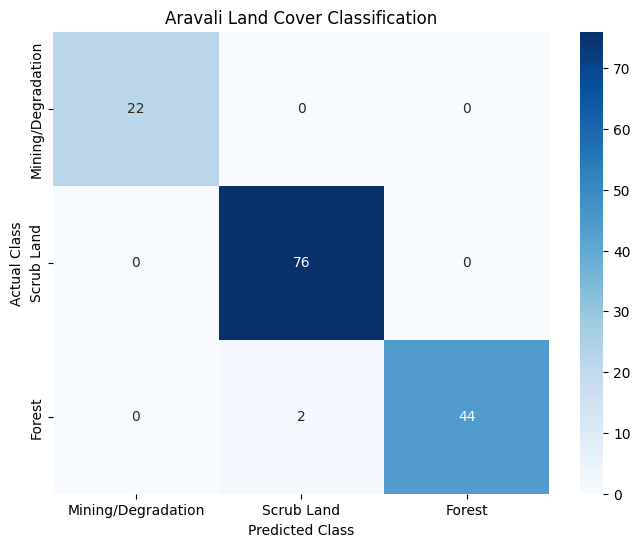


Classification Report:

                    precision    recall  f1-score   support

Mining/Degradation       1.00      1.00      1.00        22
        Scrub Land       0.97      1.00      0.99        76
            Forest       1.00      0.96      0.98        46

          accuracy                           0.99       144
         macro avg       0.99      0.99      0.99       144
      weighted avg       0.99      0.99      0.99       144



In [31]:
def plot_confusion_matrix(model, X_test, y_true):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    all_class_names = ["Mining/Degradation", "Scrub Land", "Forest"]
    
    unique_labels = np.unique(np.concatenate([y_true, y_pred]))
    current_target_names = [all_class_names[i] for i in unique_labels]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=current_target_names, 
                yticklabels=current_target_names)
    plt.title('Aravali Land Cover Classification')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, 
                                labels=unique_labels, 
                                target_names=current_target_names))

plot_confusion_matrix(model, X_test_norm, y_test_class)

In [32]:
def model_save():
    saved_model = model.save_weights("aravli_classifier_v2.weights.h5")
    print("model saved successfully")
    return saved_model 
saved_model = model_save()
saved_model

model saved successfully
